# EDA Notebook

## 1. Importar librerías necesarias
No se utilizan muchas aquí porque se importan varias funciones

In [33]:
import matplotlib.pyplot as plt
import sys

sys.path.append("..")

from src.config import RAW_PATH, OUT_PATH
from src.io import load_csv
from src.cleaning import clean
from src.features import build_features


## 2. Cargar el archivo CSV

In [34]:
df = load_csv(RAW_PATH)
df.head()

,name,description,make,model,type,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,exterior_color,interior_color,drivetrain
0,2024 Jeep Wagoneer Series II,"\n \n Heated Leather Seats, Nav Sy...",Jeep,Wagoneer,New,2024,74600.0,24V GDI DOHC Twin Turbo,6.0,Gasoline,10.0,8-Speed Automatic,Series II,SUV,4.0,White,Global Black,Four-wheel Drive
1,2024 Jeep Grand Cherokee Laredo,Al West is committed to offering every custome...,Jeep,Grand Cherokee,New,2024,50170.0,OHV,6.0,Gasoline,1.0,8-Speed Automatic,Laredo,SUV,4.0,Metallic,Global Black,Four-wheel Drive
2,2024 GMC Yukon XL Denali,NaN,GMC,Yukon XL,New,2024,96410.0,"6.2L V-8 gasoline direct injection, variable v...",8.0,Gasoline,0.0,Automatic,Denali,SUV,4.0,Summit White,Teak/Light Shale,Four-wheel Drive
3,2023 Dodge Durango Pursuit,White Knuckle Clearcoat 2023 Dodge Durango Pur...,Dodge,Durango,New,2023,46835.0,16V MPFI OHV,8.0,Gasoline,32.0,8-Speed Automatic,Pursuit,SUV,4.0,White Knuckle Clearcoat,Black,All-wheel Drive
4,2024 RAM 3500 Laramie,\n \n 2024 Ram 3500 Laramie Billet...,RAM,3500,New,2024,81663.0,24V DDI OHV Turbo Diesel,6.0,Diesel,10.0,6-Speed Automatic,Laramie,Pickup Truck,4.0,Silver,Black,Four-wheel Drive


## 3. Visualizar las primeras filas del dataset
Mostrar las primeras filas del DataFrame usando head() para obtener una vista general de los datos.

In [35]:
df.head()

,name,description,make,model,type,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,exterior_color,interior_color,drivetrain
0,2024 Jeep Wagoneer Series II,"\n \n Heated Leather Seats, Nav Sy...",Jeep,Wagoneer,New,2024,74600.0,24V GDI DOHC Twin Turbo,6.0,Gasoline,10.0,8-Speed Automatic,Series II,SUV,4.0,White,Global Black,Four-wheel Drive
1,2024 Jeep Grand Cherokee Laredo,Al West is committed to offering every custome...,Jeep,Grand Cherokee,New,2024,50170.0,OHV,6.0,Gasoline,1.0,8-Speed Automatic,Laredo,SUV,4.0,Metallic,Global Black,Four-wheel Drive
2,2024 GMC Yukon XL Denali,NaN,GMC,Yukon XL,New,2024,96410.0,"6.2L V-8 gasoline direct injection, variable v...",8.0,Gasoline,0.0,Automatic,Denali,SUV,4.0,Summit White,Teak/Light Shale,Four-wheel Drive
3,2023 Dodge Durango Pursuit,White Knuckle Clearcoat 2023 Dodge Durango Pur...,Dodge,Durango,New,2023,46835.0,16V MPFI OHV,8.0,Gasoline,32.0,8-Speed Automatic,Pursuit,SUV,4.0,White Knuckle Clearcoat,Black,All-wheel Drive
4,2024 RAM 3500 Laramie,\n \n 2024 Ram 3500 Laramie Billet...,RAM,3500,New,2024,81663.0,24V DDI OHV Turbo Diesel,6.0,Diesel,10.0,6-Speed Automatic,Laramie,Pickup Truck,4.0,Silver,Black,Four-wheel Drive


In [36]:
df.tail()

,name,description,make,model,type,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,exterior_color,interior_color,drivetrain
997,2024 Mercedes-Benz Sprinter 2500 Standard Roof,2024 Mercedes-Benz Sprinter 2500 Cargo 144 WB ...,Mercedes-Benz,Sprinter 2500,New,2024,59037.0,16V DDI DOHC Turbo Diesel,4.0,Diesel,10.0,9-Speed Automatic,Standard Roof,Cargo Van,3.0,Arctic White,Black,Rear-wheel Drive
998,2024 Dodge Hornet Hornet R/T Plus Eawd,Dealer Comments +++ Price Ends 5/31/2024 +++ A...,Dodge,Hornet,New,2024,49720.0,"4 gasoline direct injection, DOHC, Multiair va...",4.0,Gasoline,0.0,6-Spd Aisin F21-250 PHEV Auto Trans,Hornet R/T Plus Eawd,SUV,4.0,Acapulco Gold,Black,All-wheel Drive
999,2024 Jeep Wagoneer Base,\n \n The ALL New Friendship CDJR ...,Jeep,Wagoneer,New,2024,69085.0,24V GDI DOHC Twin Turbo,6.0,Gasoline,20.0,8-Speed Automatic,Base,SUV,4.0,Diamond Black,Black,Four-wheel Drive
1000,2024 Nissan Murano SV Intelligent AWD,"\n \n CVT with Xtronic, AWD.At Tod...",Nissan,Murano,New,2024,43495.0,"6 DOHC, variable valve control, regular unlead...",6.0,Gasoline,6.0,Automatic,SV Intelligent AWD,SUV,4.0,Pearl White Tricoat,Graphite,All-wheel Drive
1001,2024 Chevrolet Silverado 2500 WT,01u 2024 Chevrolet Silverado 2500HD Work Truck...,Chevrolet,Silverado 2500,New,2024,48995.0,"8 gasoline direct injection, variable valve co...",8.0,Gasoline,31.0,Automatic,WT,Pickup Truck,4.0,Wheatland Yellow,Jet Black,Rear-wheel Drive


## 4. Explorar información general del dataset
Se utiliza info() y shape para mostrar información sobre el número de filas, columnas y tipos de datos.

In [37]:
df.info()
print(f"\nNúmero de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

<class 'pandas.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            1002 non-null   str    
 1   description     946 non-null    str    
 2   make            1002 non-null   str    
 3   model           1002 non-null   str    
 4   type            1002 non-null   str    
 5   year            1002 non-null   int64  
 6   price           979 non-null    float64
 7   engine          1000 non-null   str    
 8   cylinders       897 non-null    float64
 9   fuel            995 non-null    str    
 10  mileage         968 non-null    float64
 11  transmission    1000 non-null   str    
 12  trim            1001 non-null   str    
 13  body            999 non-null    str    
 14  doors           995 non-null    float64
 15  exterior_color  997 non-null    str    
 16  interior_color  964 non-null    str    
 17  drivetrain      1002 non-null   str    
dtyp

## 5. Describir variables numéricas
Se utiliza describe() para variables numéricas.

In [38]:
df.describe()


,year,price,cylinders,mileage,doors
count,1002.000000,979.000000,897.000000,968.000000,995.000000
mean,2023.916168,50202.985700,4.975474,69.033058,3.943719
std,0.298109,18700.392062,1.392526,507.435745,0.274409
min,2023.000000,0.000000,0.000000,0.000000,2.000000
25%,2024.000000,36600.000000,4.000000,4.000000,4.000000
50%,2024.000000,47165.000000,4.000000,8.000000,4.000000
75%,2024.000000,58919.500000,6.000000,13.000000,4.000000
max,2025.000000,195895.000000,8.000000,9711.000000,5.000000


## 6. Visualizar valores nulos y duplicados
Se identifica y visualiza la cantidad de valores nulos y filas duplicadas en el dataset.

In [39]:
# Null values
print(f"El numero de nulos para cada columna es:\n{df.isnull().sum().sort_values(ascending=False)}")

# Duplicated rows
print()
print(f"El número de filas duplicadas es: {df.duplicated().sum()}")

El numero de nulos para cada columna es:
cylinders         105
description        56
interior_color     38
mileage            34
price              23
fuel                7
doors               7
exterior_color      5
body                3
engine              2
transmission        2
trim                1
name                0
year                0
make                0
model               0
type                0
drivetrain          0
dtype: int64

El número de filas duplicadas es: 24


## 7. Limpiar datos

Se realizan los siguientes pasos para la limpieza:

- eliminar duplicados
- quitar filas sin precio o con precio 0
- rellenar valores nulos con la mediana
- limpiar textos con espacios

In [40]:
df_clean = clean(df)

print("Filas antes:", len(df))
print("Filas después:", len(df_clean))
print("Filas eliminadas:", len(df) - len(df_clean))

df_clean.head()

Filas antes: 1002
Filas después: 978
Filas eliminadas: 24


,name,description,make,model,type,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,exterior_color,interior_color,drivetrain
0,2024 Jeep Wagoneer Series II,"Heated Leather Seats, Nav System, Moonroof, Th...",Jeep,Wagoneer,New,2024,74600.0,24V GDI DOHC Twin Turbo,6.0,Gasoline,10.0,8-Speed Automatic,Series II,SUV,4.0,White,Global Black,Four-wheel Drive
1,2024 Jeep Grand Cherokee Laredo,Al West is committed to offering every custome...,Jeep,Grand Cherokee,New,2024,50170.0,OHV,6.0,Gasoline,1.0,8-Speed Automatic,Laredo,SUV,4.0,Metallic,Global Black,Four-wheel Drive
2,2024 GMC Yukon XL Denali,Unknown,GMC,Yukon XL,New,2024,96410.0,"6.2L V-8 gasoline direct injection, variable v...",8.0,Gasoline,0.0,Automatic,Denali,SUV,4.0,Summit White,Teak/Light Shale,Four-wheel Drive
3,2023 Dodge Durango Pursuit,White Knuckle Clearcoat 2023 Dodge Durango Pur...,Dodge,Durango,New,2023,46835.0,16V MPFI OHV,8.0,Gasoline,32.0,8-Speed Automatic,Pursuit,SUV,4.0,White Knuckle Clearcoat,Black,All-wheel Drive
4,2024 RAM 3500 Laramie,2024 Ram 3500 Laramie Billet Silver Metallic C...,RAM,3500,New,2024,81663.0,24V DDI OHV Turbo Diesel,6.0,Diesel,10.0,6-Speed Automatic,Laramie,Pickup Truck,4.0,Silver,Black,Four-wheel Drive


## 5. Crear nuevas features

Se añaden 3 columnas nuevas:

- `vehicle_age`: edad aproximada del vehículo.
- `mileage_per_year`: kilometraje medio por año.
- `price_level`: nivel de precio bajo, medio o alto.

In [41]:
df_features = build_features(df_clean)

df_features[["year", "price", "mileage", "vehicle_age", "mileage_per_year", "price_level"]].head()

,year,price,mileage,vehicle_age,mileage_per_year,price_level
0,2024,74600.0,10.0,2,3.333333,Alto
1,2024,50170.0,1.0,2,0.333333,Medio
2,2024,96410.0,0.0,2,0.000000,Alto
3,2023,46835.0,32.0,3,8.000000,Medio
4,2024,81663.0,10.0,2,3.333333,Alto


## 6. Preguntas y Visualización

### Pregunta 1: ¿Qué marcas aparecen más en el dataset?

In [42]:
df_features["make"].value_counts().head(10)

make
Jeep          192
Hyundai       120
Dodge         111
Ford           83
RAM            77
Kia            52
Chevrolet      49
Nissan         40
Volkswagen     38
Mazda          38
Name: count, dtype: Int64

### Gráfico 1: Marcas con más vehículos

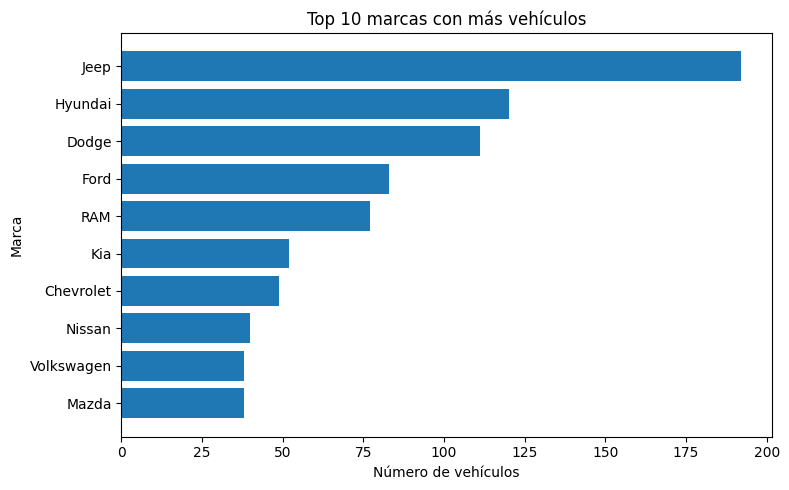

In [43]:
top_marcas = df_features["make"].value_counts().head(10).sort_values()

plt.figure(figsize=(8, 5))
plt.barh(top_marcas.index, top_marcas.values)
plt.title("Top 10 marcas con más vehículos")
plt.xlabel("Número de vehículos")
plt.ylabel("Marca")
plt.tight_layout()
plt.show()

Se puede apreciar como Jeep es la marca que más aparece, seguida de Hyundai y Dodge

### Pregunta 2: ¿Qué marcas tienen mayor precio medio?

In [44]:
df_features.groupby("make")["price"].mean().sort_values(ascending=False).head(10).round(2)


make
BMW              91366.39
Mercedes-Benz    81110.15
Audi             79318.00
Jaguar           77053.00
Lexus            73270.00
Genesis          71007.50
RAM              68712.23
Volvo            65126.67
Land Rover       63162.75
GMC              61221.30
Name: price, dtype: float64

### Gráfico 2: Precio medio por marca

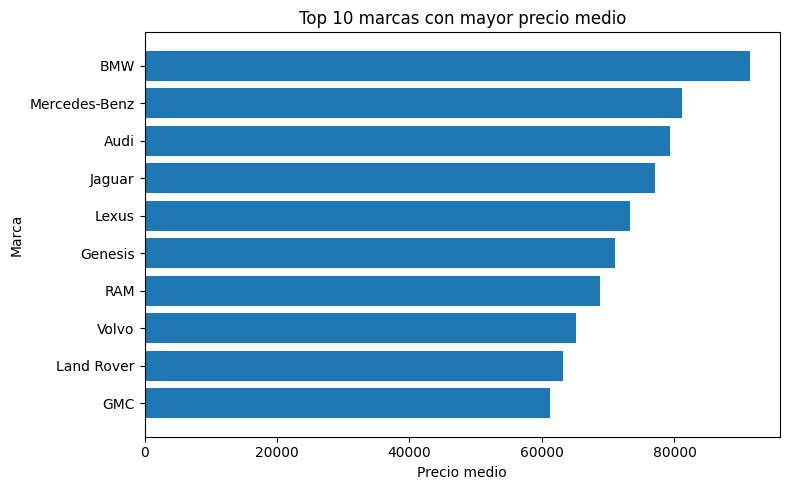

In [45]:
precio_marca = df_features.groupby("make")["price"].mean()
precio_marca = precio_marca.sort_values(ascending=False).head(10)
precio_marca = precio_marca.sort_values()

plt.figure(figsize=(8, 5))
plt.barh(precio_marca.index, precio_marca.values)
plt.title("Top 10 marcas con mayor precio medio")
plt.xlabel("Precio medio")
plt.ylabel("Marca")
plt.tight_layout()
plt.show()

Como se esperaba y se puede observar, BMW, Mercedes y Audi son las marcas con el mayor precio medio.

### Pregunta 3: ¿Los vehículos con más kilometraje suelen ser más baratos?

In [46]:
mileage_price = df_features[["mileage", "price"]].corr().loc["mileage", "price"]
print("Correlación entre kilometraje y precio:", round(mileage_price, 3))

Correlación entre kilometraje y precio: 0.078


### Gráfico 3: Relación entre kilometraje y precio

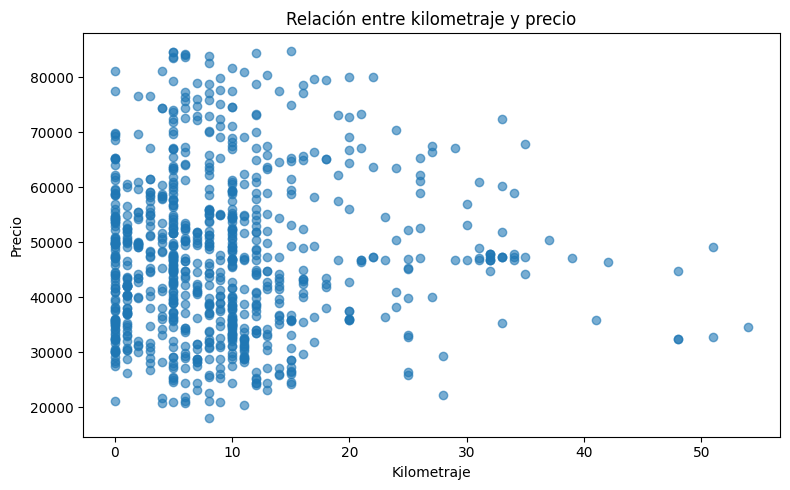

In [29]:
datos = df_features[["mileage", "price"]].dropna()

datos = datos[datos["mileage"] <= datos["mileage"].quantile(0.95)]
datos = datos[datos["price"] <= datos["price"].quantile(0.95)]

plt.figure(figsize=(8, 5))
plt.scatter(datos["mileage"], datos["price"], alpha=0.6)
plt.title("Relación entre kilometraje y precio")
plt.xlabel("Kilometraje")
plt.ylabel("Precio")
plt.tight_layout()
plt.show()

correlacion = datos["mileage"].corr(datos["price"])

El valor de la correlación es muy bajo, esto indica que el kilometraje puede afectar al precio pero no explica por si solo

### Pregunta 4: ¿Qué tipos de combustible son más habituales?

In [47]:
df_features["fuel"].value_counts().head(10)

fuel
Gasoline                646
Hybrid                  135
Electric                 96
Diesel                   72
PHEV Hybrid Fuel         16
Unknown                   7
E85 Flex Fuel             5
Diesel (B20 capable)      1
Name: count, dtype: Int64

### Gráfico 4: Vehículos por tipo de combustible

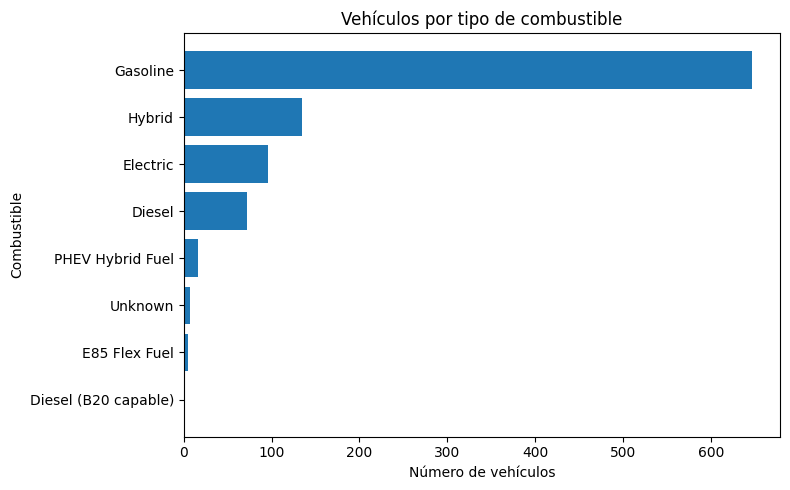

In [48]:
combustibles = df_features["fuel"].value_counts().head(8).sort_values()

plt.figure(figsize=(8, 5))
plt.barh(combustibles.index, combustibles.values)
plt.title("Vehículos por tipo de combustible")
plt.xlabel("Número de vehículos")
plt.ylabel("Combustible")
plt.tight_layout()
plt.show()

Para mi sorpresa, se puede apreciar como los vehículos de diesel han caído por detrás de los hibridos y eléctricos. Siendo aún laa gasolina el combustible más habitual

### Pregunta 5: ¿Cómo cambia el precio medio según la edad del vehículo?

In [49]:
df_features.groupby("vehicle_age")["price"].mean().sort_index(ascending=True).head().round(2)

vehicle_age
1    51020.83
2    50322.65
3    49515.65
Name: price, dtype: float64

### Gráfico 5: Precio medio según la edad del vehículo

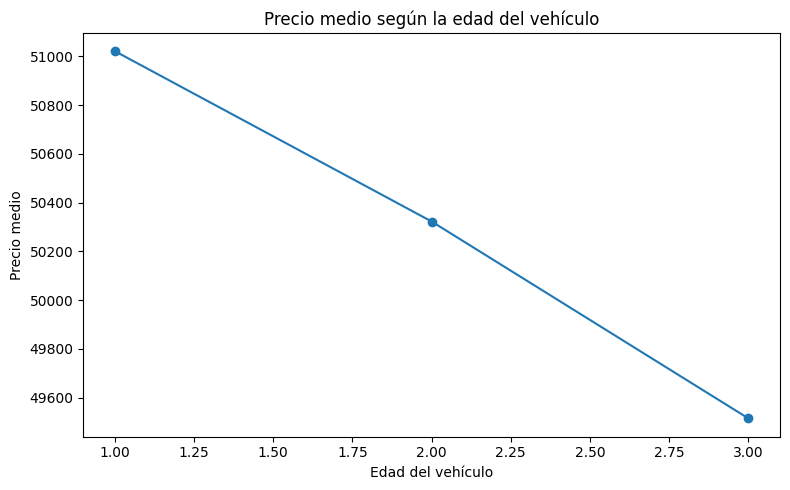

In [50]:
precio_edad = df_features.groupby("vehicle_age")["price"].mean()
precio_edad = precio_edad.sort_index()
precio_edad = precio_edad[precio_edad.index <= 30]

plt.figure(figsize=(8, 5))
plt.plot(precio_edad.index, precio_edad.values, marker="o")
plt.title("Precio medio según la edad del vehículo")
plt.xlabel("Edad del vehículo")
plt.ylabel("Precio medio")
plt.tight_layout()
plt.show()

Se puede apreciar como a medida que van pasando los años el precio va descendiendo

## 7. Guardar dataset limpio

In [51]:
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df_features.to_csv(OUT_PATH, index=False)
print("Dataset guardado en:", OUT_PATH)

Dataset guardado en: C:\Users\mforq\Dropbox\PC\Documents\EVOLVE\proyecto_inicial_EDA\data\processed\clean_dataset.csv


## 8. Conclusiones

1. En el gráfico de distribución de precios se ve que la mayoría de coches están en rangos de precio bajos o medios, y hay menos coches con precios muy altos.
2. En el gráfico de kilometraje y precio se observa que el kilometraje influye en el precio, aunque no es el único factor importante.
3. En los gráficos por marca y combustible se ve que el dataset no está equilibrado: algunas marcas y tipos de combustible aparecen mucho más que otros.